In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\Adip Deb\Downloads\iphone_sales_dataset.csv")

df.head()

,Order_ID,Customer_Name,Country,iPhone_Model,Storage,Color,Quantity,Price,Sale_Date,Payment_Method
0,1001,Customer_1,USA,iPhone 13,256GB,Purple,5,1817,2025-05-01,Debit Card
1,1002,Customer_2,Canada,iPhone 12,256GB,Blue,1,998,2025-03-05,PayPal
2,1003,Customer_3,Canada,iPhone 15 Pro Max,512GB,Black,5,876,2025-01-25,Credit Card
3,1004,Customer_4,USA,iPhone 15 Pro Max,512GB,Black,2,1290,2025-03-24,Debit Card
4,1005,Customer_5,USA,iPhone 15,128GB,Blue,3,1092,2025-02-01,Debit Card


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Order_ID        100 non-null    int64 
 1   Customer_Name   100 non-null    object
 2   Country         100 non-null    object
 3   iPhone_Model    100 non-null    object
 4   Storage         100 non-null    object
 5   Color           100 non-null    object
 6   Quantity        100 non-null    int64 
 7   Price           100 non-null    int64 
 8   Sale_Date       100 non-null    object
 9   Payment_Method  100 non-null    object
dtypes: int64(3), object(7)
memory usage: 7.9+ KB


In [4]:
df["Sale_Date"] = pd.to_datetime(df["Sale_Date"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        100 non-null    int64         
 1   Customer_Name   100 non-null    object        
 2   Country         100 non-null    object        
 3   iPhone_Model    100 non-null    object        
 4   Storage         100 non-null    object        
 5   Color           100 non-null    object        
 6   Quantity        100 non-null    int64         
 7   Price           100 non-null    int64         
 8   Sale_Date       100 non-null    datetime64[ns]
 9   Payment_Method  100 non-null    object        
dtypes: datetime64[ns](1), int64(3), object(6)
memory usage: 7.9+ KB


In [5]:
df.isnull().sum()

Order_ID          0
Customer_Name     0
Country           0
iPhone_Model      0
Storage           0
Color             0
Quantity          0
Price             0
Sale_Date         0
Payment_Method    0
dtype: int64

In [6]:
df["Order_ID"].duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,Order_ID,Quantity,Price,Sale_Date
count,100.000000,100.000000,100.000000,100
mean,1050.500000,3.330000,1468.750000,2025-02-27 12:28:48
min,1001.000000,1.000000,718.000000,2025-01-01 00:00:00
25%,1025.750000,2.000000,1123.750000,2025-01-25 00:00:00
50%,1050.500000,3.000000,1571.500000,2025-03-02 00:00:00
75%,1075.250000,5.000000,1794.250000,2025-03-28 00:00:00
max,1100.000000,5.000000,1992.000000,2025-05-01 00:00:00
std,29.011492,1.484295,388.367637,NaN


In [8]:
print("Countries:")
print(df["Country"].unique())

print("\n iPhone Models:")
print(df["iPhone_Model"].unique())

print("\nStorage Options:")
print(df["Storage"].unique())

print("\nPayment Methods:")
print(df["Payment_Method"].unique())

print("\nColors:")
print(df["Color"].unique())

Countries:
['USA' 'Canada' 'UAE' 'Germany' 'UK' 'Pakistan']

 iPhone Models:
['iPhone 13' 'iPhone 12' 'iPhone 15 Pro Max' 'iPhone 15' 'iPhone 14 Pro'
 'iPhone 14']

Storage Options:
['256GB' '512GB' '128GB']

Payment Methods:
['Debit Card' 'PayPal' 'Credit Card' 'Cash']

Colors:
['Purple' 'Blue' 'Black' 'Red' 'White']


In [9]:
df["Country"].value_counts()

Country
USA         22
UK          22
Canada      18
UAE         17
Germany     11
Pakistan    10
Name: count, dtype: int64

In [10]:
country_sales = df.groupby("Country")["Price"].sum().sort_values(ascending=False)

country_sales

Country
USA         33451
UK          33148
Canada      26289
UAE         25085
Germany     16515
Pakistan    12387
Name: Price, dtype: int64

In [11]:
country_sales

Country
USA         33451
UK          33148
Canada      26289
UAE         25085
Germany     16515
Pakistan    12387
Name: Price, dtype: int64

In [12]:
model_sales = df.groupby("iPhone_Model")["Price"].sum().sort_values(ascending=False)

model_sales

iPhone_Model
iPhone 14 Pro        36612
iPhone 15 Pro Max    30366
iPhone 15            22608
iPhone 13            21017
iPhone 12            19364
iPhone 14            16908
Name: Price, dtype: int64

In [13]:
model_units = df.groupby("iPhone_Model")["Quantity"].sum().sort_values(ascending=False)

model_units

iPhone_Model
iPhone 15 Pro Max    73
iPhone 14 Pro        66
iPhone 13            59
iPhone 15            57
iPhone 12            42
iPhone 14            36
Name: Quantity, dtype: int64

In [14]:
monthly_sales = df.groupby(df["Sale_Date"].dt.to_period("M"))["Price"].sum()

monthly_sales

Sale_Date
2025-01    46129
2025-02    28362
2025-03    39029
2025-04    29559
2025-05     3796
Freq: M, Name: Price, dtype: int64

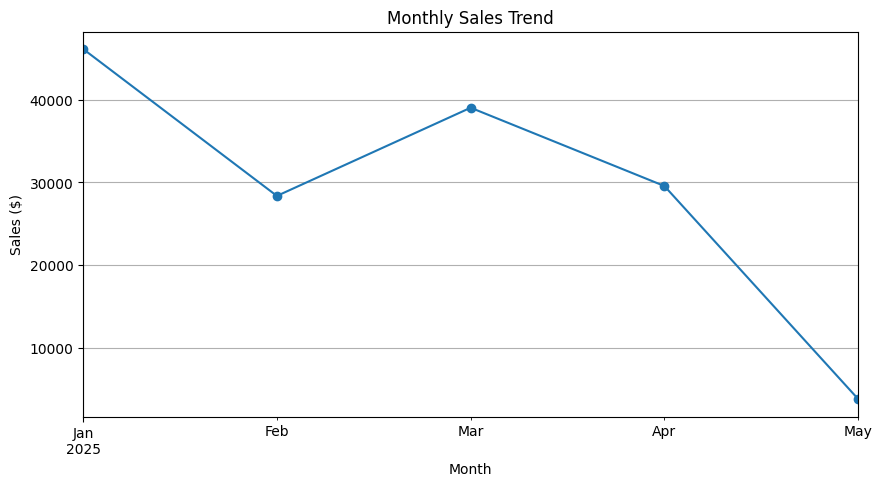

In [15]:
monthly_sales.plot(kind="line", marker="o", figsize=(10, 5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.grid(True)
plt.show()

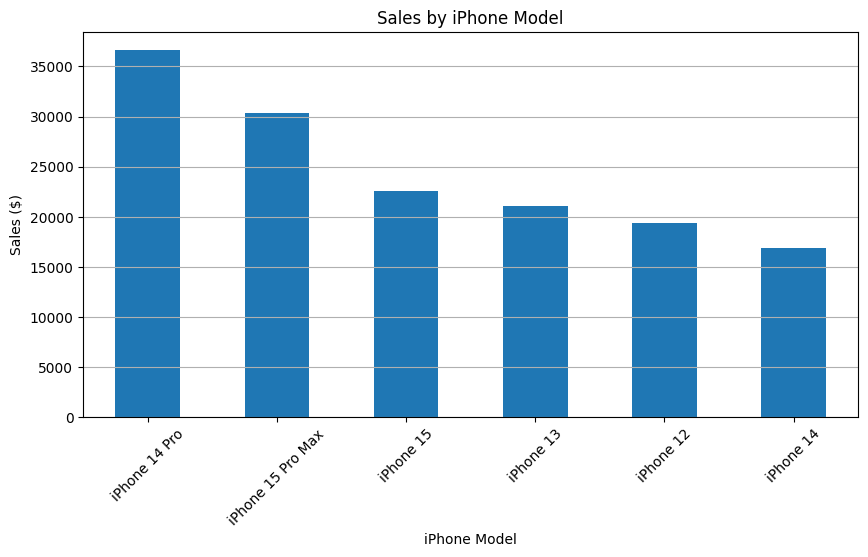

In [16]:
model_sales.plot(kind="bar", figsize=(10, 5))

plt.title("Sales by iPhone Model")
plt.xlabel("iPhone Model")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

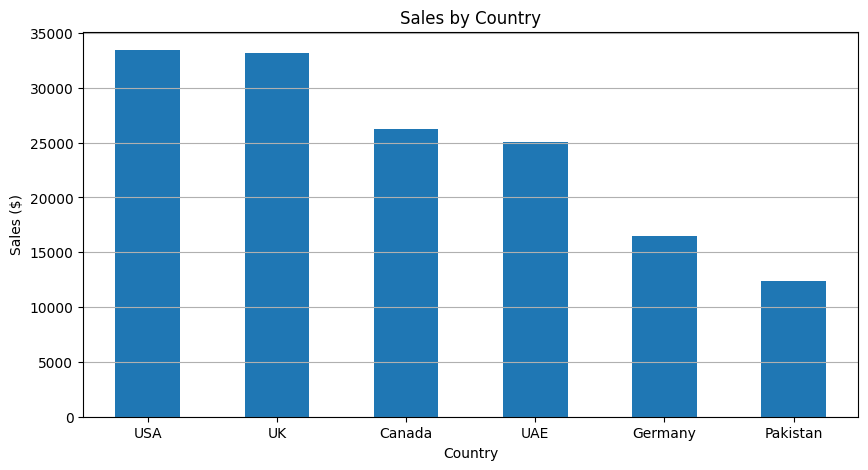

In [17]:
country_sales.plot(kind="bar", figsize=(10, 5))

plt.title("Sales by Country")
plt.xlabel("Country")
plt.ylabel("Sales ($)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

In [18]:
storage_sales = df.groupby("Storage")["Price"].agg(["sum", "count"])
storage_sales


,sum,count
Storage,,
128GB,50676,34
256GB,53664,38
512GB,42535,28


In [19]:
storage_units = df.groupby("Storage")["Quantity"].sum().sort_values(ascending=False)
storage_units

Storage
256GB    127
128GB    107
512GB     99
Name: Quantity, dtype: int64

In [20]:
payment_sales = df.groupby("Payment_Method")["Price"].agg(["sum", "count"]).sort_values("sum", ascending=False)

payment_sales

,sum,count
Payment_Method,,
Debit Card,55425,38
Credit Card,37832,25
PayPal,26902,18
Cash,26716,19


In [21]:
total_orders = df["Order_ID"].nunique()
total_units = df["Quantity"].sum()
total_sales = df["Price"].sum()
average_order_value = df["Price"].mean()

print("Total Orders:", total_orders)
print("Total Units Sold:", total_units)
print("Total Sales: $", total_sales)
print("Average Order Value: $", round(average_order_value, 2))

Total Orders: 100
Total Units Sold: 333
Total Sales: $ 146875
Average Order Value: $ 1468.75


In [22]:
top_orders = df.nlargest(10, "Price")[[
    "Order_ID",
    "Customer_Name",
    "Country",
    "iPhone_Model",
    "Storage",
    "Quantity",
    "Price"
]]

top_orders

,Order_ID,Customer_Name,Country,iPhone_Model,Storage,Quantity,Price
16,1017,Customer_17,Germany,iPhone 13,512GB,5,1992
63,1064,Customer_64,UK,iPhone 15 Pro Max,512GB,2,1991
73,1074,Customer_74,Germany,iPhone 15 Pro Max,256GB,1,1987
70,1071,Customer_71,UK,iPhone 12,512GB,2,1977
92,1093,Customer_93,UK,iPhone 12,256GB,3,1971
22,1023,Customer_23,USA,iPhone 15,128GB,5,1964
71,1072,Customer_72,UAE,iPhone 12,128GB,5,1964
28,1029,Customer_29,Canada,iPhone 14 Pro,256GB,3,1963
52,1053,Customer_53,USA,iPhone 14 Pro,128GB,1,1959
5,1006,Customer_6,UAE,iPhone 14 Pro,256GB,5,1939


In [23]:
df.groupby("Quantity")["Price"].agg(["count", "mean", "sum"])


,count,mean,sum
Quantity,,,
1,18,1438.666667,25896
2,12,1378.666667,16544
3,21,1451.571429,30483
4,17,1514.117647,25740
5,32,1506.625000,48212


In [24]:
df[["Quantity", "Price"]].corr()

,Quantity,Price
Quantity,1.000000,0.093909
Price,0.093909,1.000000


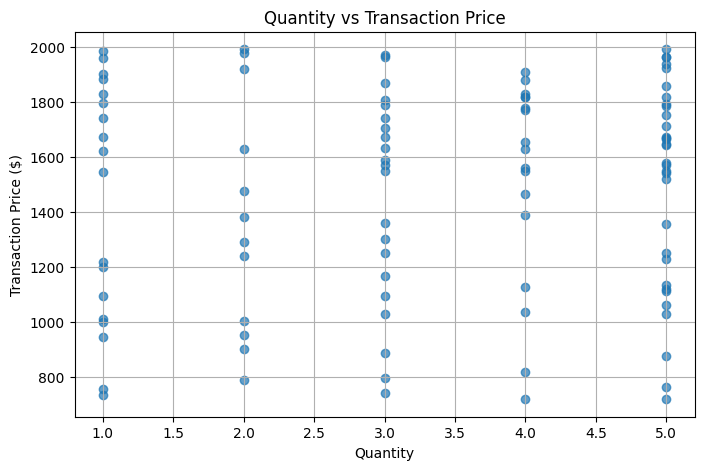

In [25]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Quantity"], df["Price"], alpha=0.7)

plt.title("Quantity vs Transaction Price")
plt.xlabel("Quantity")
plt.ylabel("Transaction Price ($)")
plt.grid(True)

plt.show()

In [26]:
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Price"] < lower_bound) |
    (df["Price"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Potential Outliers:", len(outliers))

Q1: 1123.75
Q3: 1794.25
IQR: 670.5
Lower Bound: 118.0
Upper Bound: 2800.0
Potential Outliers: 0


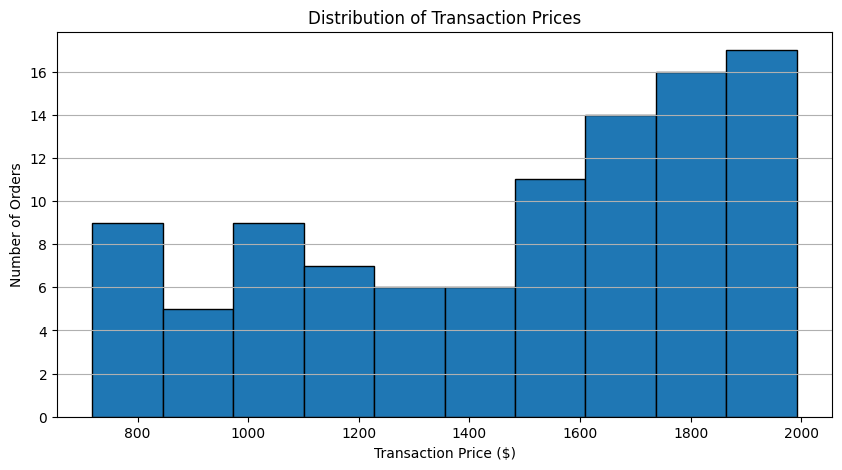

In [27]:
plt.figure(figsize=(10, 5))

plt.hist(df["Price"], bins=10, edgecolor="black")

plt.title("Distribution of Transaction Prices")
plt.xlabel("Transaction Price ($)")
plt.ylabel("Number of Orders")
plt.grid(axis="y")

plt.show()